# Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np

In [2]:
#Load the CSV file using Pandas
df=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [3]:
# Display the first 10 rows
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [4]:
# Check how many rows and columns are there
df.shape

(1470, 35)

In [5]:
# Check how many rows
df.shape[0]

1470

In [6]:
# Check how many columns
df.shape[1]

35

In [7]:
# Identify the target column (Attrition — Yes/No)
print("Target_Col:", "Attrition")

Target_Col: Attrition


In [8]:
# Count how many employees left vs stayed 
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [9]:
#  calculate the attrition rate as a percentage
attrition_rate = (df["Attrition"] == "Yes").mean() * 100
print("Attrition_rate:", (attrition_rate), "%")

Attrition_rate: 16.122448979591837 %


In [10]:
# Identify how many columns are numeric vs categorical
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
catg_cols = df.select_dtypes(include=["object"]).columns
print("Numeric Columns:", len(num_cols))
print("Categorical Columns:", len(catg_cols))

Numeric Columns: 26
Categorical Columns: 9


 <!-- Write one observation: what do you notice about the attrition rate — is it balanced orimbalanced? -->


# Write one observation: what do you notice about the attrition rate — is it balanced or imbalanced?
# From the dataset, I noticed that most employees did not leave the company. Only a small percentage of employees left. This means the dataset is imbalanced, so I will use appropriate techniques during model building to handle this imbalance.

# Task 2: Data Cleaning & Preprocessing 

In [11]:
 # Check for missing/null values and handle them
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [12]:
# Drop columns that add no value to prediction (e.g., EmployeeNumber, Over18,StandardHours — these are constant or irrelevant)
df = df.drop(columns=['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'])

In [13]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,4,Male,...,3,3,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,3,Female,...,4,1,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,4,Male,...,4,2,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,4,Male,...,4,2,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,3,Male,...,3,2,2,17,3,2,7,7,7,7


In [14]:
# Convert the target column Attrition from Yes/No to 1/0
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

In [15]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
5,32,0,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,4,Male,...,3,3,0,8,2,2,7,7,3,6
6,59,0,Travel_Rarely,1324,Research & Development,3,3,Medical,3,Female,...,4,1,3,12,3,2,1,0,0,0
7,30,0,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,4,Male,...,4,2,1,1,2,3,1,0,0,0
8,38,0,Travel_Frequently,216,Research & Development,23,3,Life Sciences,4,Male,...,4,2,0,10,2,3,9,7,1,8
9,36,0,Travel_Rarely,1299,Research & Development,27,3,Medical,3,Male,...,3,2,2,17,3,2,7,7,7,7


In [16]:
# Encode all remaining categorical columns using One-Hot Encoding (e.g.,Department, JobRole, MaritalStatus, BusinessTravel)
catg_cols = df.select_dtypes(include="object").columns
print(catg_cols)
df = pd.get_dummies(df, columns=catg_cols, drop_first=True)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [17]:
df.head(10)

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False
5,32,0,1005,2,2,4,79,3,1,4,...,True,False,False,False,False,False,False,False,True,False
6,59,0,1324,3,3,3,81,4,1,1,...,True,False,False,False,False,False,False,True,False,True
7,30,0,1358,24,1,4,67,3,1,3,...,True,False,False,False,False,False,False,False,False,False
8,38,0,216,23,3,4,44,2,3,3,...,False,False,True,False,False,False,False,False,True,False
9,36,0,1299,27,3,3,94,3,2,3,...,False,False,False,False,False,False,False,True,False,False


In [18]:
 # Separate Features and Target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]


In [19]:
X

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,True,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,3,41,4,2,4,2571,...,True,False,False,False,False,False,False,True,False,False
1466,39,613,6,1,4,42,2,3,1,9991,...,False,False,False,False,False,False,False,True,False,False
1467,27,155,4,3,2,87,4,2,2,6142,...,False,False,True,False,False,False,False,True,False,True
1468,49,1023,2,3,4,63,2,2,2,5390,...,False,False,False,False,False,True,False,True,False,False


In [20]:
y

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64

In [21]:
# Scale numeric features using StandardScaler
from sklearn.preprocessing import StandardScaler
scal=StandardScaler()
X_scal=scal.fit_transform(X)

In [22]:
print(X_scal.shape)
print(y.shape)

(1470, 44)
(1470,)


# Task 3 — Exploratory Data Analysis — EDA


Attrition                      No        Yes
Department                                  
Human Resources         80.952381  19.047619
Research & Development  86.160250  13.839750
Sales                   79.372197  20.627803


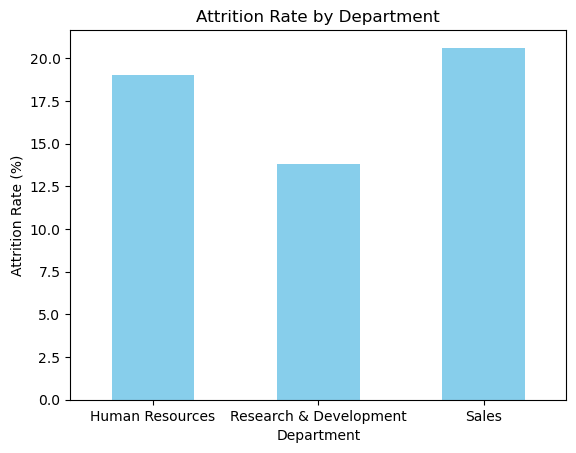

In [23]:
# Attrition rate by Department — which department loses the most employees?
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
eda_df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
depart_attrition = (eda_df.groupby("Department")["Attrition"].value_counts(normalize=True).unstack() * 100)
print(depart_attrition)
depart_attrition["Yes"].plot(kind="bar", color="skyblue")
plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.show()

Attrition                         No        Yes
JobRole                                        
Sales Representative       60.240964  39.759036
Laboratory Technician      76.061776  23.938224
Human Resources            76.923077  23.076923
Sales Executive            82.515337  17.484663
Research Scientist         83.904110  16.095890
Manufacturing Director     93.103448   6.896552
Healthcare Representative  93.129771   6.870229
Manager                    95.098039   4.901961
Research Director          97.500000   2.500000


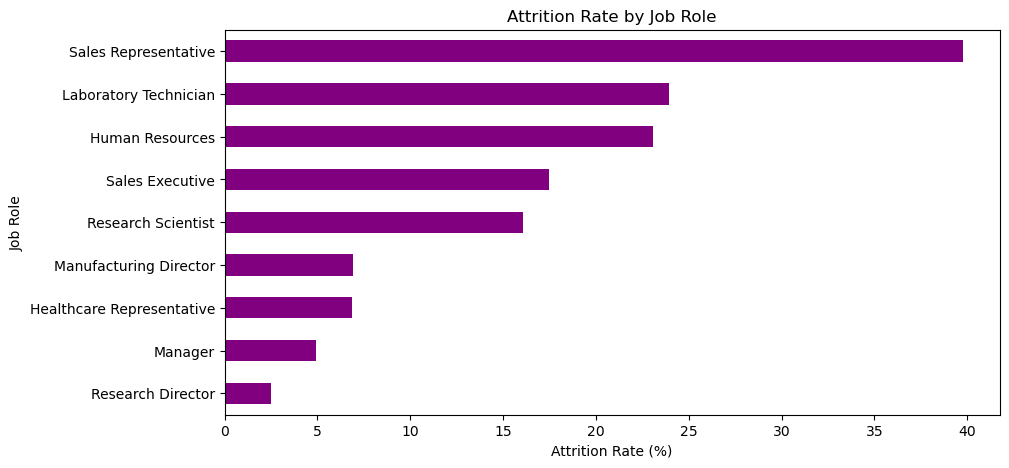

In [24]:
# Attrition rate by Job Role — which roles have the highest exit rate?
jobrole_attrition = (eda_df.groupby("JobRole")["Attrition"].value_counts(normalize=True).unstack() * 100)
print(jobrole_attrition.sort_values(by="Yes", ascending=False))
plt.figure(figsize=(10,5))
jobrole_attrition["Yes"].sort_values().plot(kind="barh",color="purple")
plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")
plt.show()

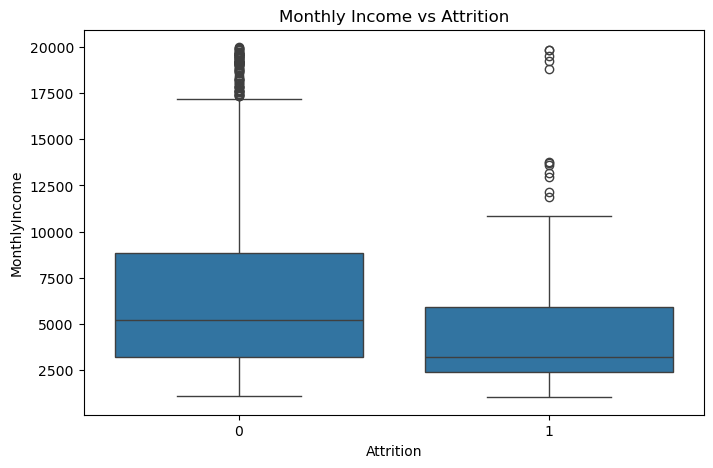

In [25]:
# Attrition vs Monthly Income — do lower paid employees leave more?
plt.figure(figsize=(8,5))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64


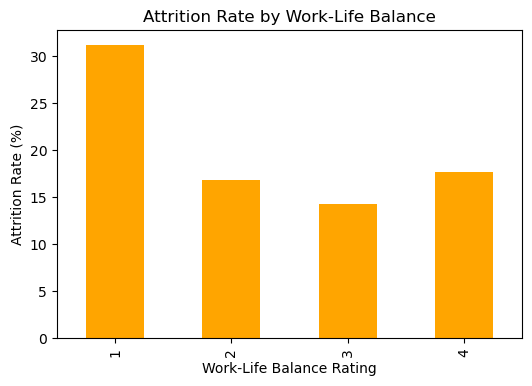

In [26]:
# Attrition vs Work-Life Balance rating — is there a visible pattern?
worklife_df = eda_df.copy()
worklife_df["Attrition"] = worklife_df["Attrition"].map({"Yes": 1, "No": 0})
worklife = worklife_df.groupby("WorkLifeBalance")["Attrition"].mean() * 100
print(worklife)
plt.figure(figsize=(6,4))
worklife.plot(kind="bar", color="orange")
plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Rate (%)")

plt.show()

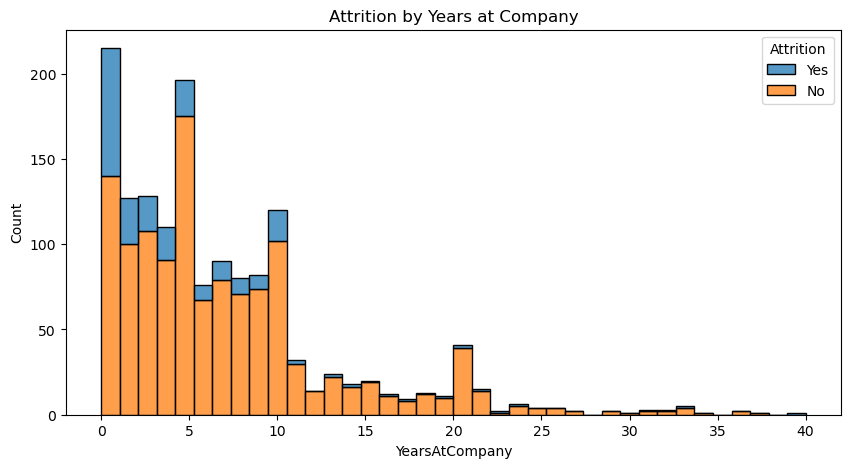

In [27]:
# Attrition vs Years at Company — at what point in tenure do employees leave most?
plt.figure(figsize=(10,5))
sns.histplot(data=eda_df, x="YearsAtCompany", hue="Attrition", multiple="stack")
plt.title("Attrition by Years at Company")
plt.show()

# Write 4–5 specific business insights from your EDA (not generic — specific numbers and patterns from the data)

In [28]:
## Business Insights
# 1. The Sales department has the highest attrition rate (aound 20.0%), compared to the Research & Development and Human Resources departments. This indicates that employees in the Sales department are leaving the company more frequently, so HR should focus on improving employee satisfaction and retention in this department.
# 2. Among different job roles, Sales Representatives and Laboratory Technicians show higher attrition rates than other roles. This suggests that employees in these positions may be facing challenges such as workload, career growth, or job satisfaction.
# 3. Employees with lower monthly income are more likely to leave the company than employees with higher salaries. This pattern indicates that compensation may play an important role in employee retention.
# 4. Employees who have lower Work-Life Balance ratings show a higher attrition rate. Maintaining a healthy balance between work and personal life could help reduce employee turnover.
# 5. Most employees who leave the company have fewer years of service, especially during the first few years of employment. This suggests that the company should strengthen onboarding, training, and employee engagement programs for new employees.

# Task 4 — Model Building & Comparison

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)

In [30]:
# Prepare Features and Target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [31]:
# Split data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1176, 44)
Testing Data: (294, 44)


In [32]:
# Handle class imbalance using class_weight='balanced' parameter (a simplerapproach than SMOTE — good to know both exist)
model_df = eda_df.copy()
model_df["Attrition"] = model_df["Attrition"].map({"Yes": 1, "No": 0})
model_df = model_df.drop(columns=["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"])
model_df = pd.get_dummies(model_df, drop_first=True)
X = model_df.drop("Attrition", axis=1)
y = model_df["Attrition"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1176, 44)
Testing Data: (294, 44)


In [33]:
# Train the following 3 models:
# ○ Logistic Regression (baseline — also the most explainable to HR teams)
# ○ Random Forest Classifier
# ○ Gradient Boosting Classifier
from sklearn.preprocessing import StandardScaler
scal = StandardScaler()
X_train_scal = scal.fit_transform(X_train)
X_test_scal= scal.transform(X_test)
# ○ Logistic Regression
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(class_weight="balanced",random_state=42, max_iter=5000)
log_model.fit(X_train_scal, y_train)
log_pred = log_model.predict(X_test_scal)

In [34]:
print(log_pred)

[0 0 0 0 1 1 0 0 0 0 0 1 1 1 1 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0
 0 0 1 0 1 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0
 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 0 1 0 0 1 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 1 0 0 1 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 1 0
 0 0 0 0 0 0 0 1 1 0 1 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 0 1 0 0 0 1 1 0 1 0
 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0
 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 1 0 0 1 0 0 0 1 0 1 0 1 1 0 0 1 0 0]


In [35]:
# ○ Random Forest Classifier
rf_model = RandomForestClassifier(class_weight="balanced",random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [36]:
print(rf_pred)

[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [37]:
# ○ Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

In [38]:
print(gb_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]


In [39]:
# Record all results in a comparison table inside your notebook
def evaluate_model(name, y_true, y_pred):
   return {"Model": name,"Accuracy": accuracy_score(y_true, y_pred),"Precision": precision_score(y_true, y_pred),"Recall": recall_score(y_true, y_pred),"F1-Score": f1_score(y_true, y_pred)}
results = []
results.append(evaluate_model("Logistic Regression", y_test, log_pred))
results.append(evaluate_model("Random Forest", y_test, rf_pred))
results.append(evaluate_model("Gradient Boosting", y_test, gb_pred))
comparison_table = pd.DataFrame(results)
comparison_table

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.751701,0.345238,0.617021,0.442748
1,Random Forest,0.836735,0.444444,0.085106,0.142857
2,Gradient Boosting,0.850340,0.588235,0.212766,0.312500


# Task 5: Model Evaluation

In [40]:
# Evaluate all 3 models using:
# ○ Precision, Recall, F1-Score
# ○ ROC-AUC Score
# ○ Confusion Matrix
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report)


In [41]:
# Evaluate Logistic Regression
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)
log_auc = roc_auc_score(y_test, log_pred)
print("Accuracy :", log_accuracy)
print("Precision:", log_precision)
print("Recall   :", log_recall)
print("F1 Score :", log_f1)
print("ROC AUC  :", log_auc)

Accuracy : 0.7517006802721088
Precision: 0.34523809523809523
Recall   : 0.6170212765957447
F1 Score : 0.44274809160305345
ROC AUC  : 0.6971746059092083


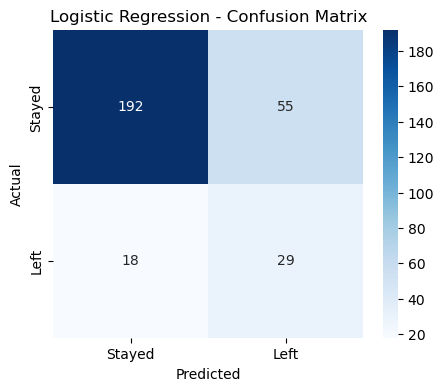

In [42]:
# Confusion Matrix
cm = confusion_matrix(y_test, log_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=["Stayed","Left"],yticklabels=["Stayed","Left"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [43]:
# Evaluate Random Forest
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_pred)
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC AUC  :", rf_auc)

Accuracy : 0.8367346938775511
Precision: 0.4444444444444444
Recall   : 0.0851063829787234
F1 Score : 0.14285714285714285
ROC AUC  : 0.5324317339994831


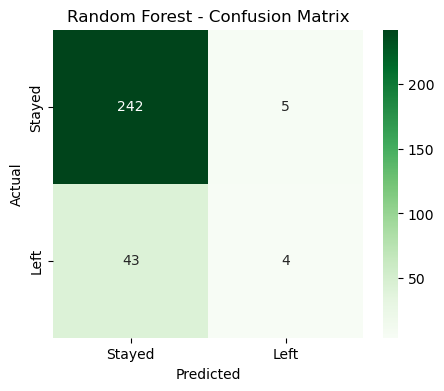

In [44]:
# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens',xticklabels=["Stayed","Left"],yticklabels=["Stayed","Left"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [45]:
# Evaluate Gradient Boosting
gb_pred = gb_model.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)
gb_auc = roc_auc_score(y_test, gb_pred)
print("Accuracy :", gb_accuracy)
print("Precision:", gb_precision)
print("Recall   :", gb_recall)
print("F1 Score :", gb_f1)
print("ROC AUC  :", gb_auc)

Accuracy : 0.8503401360544217
Precision: 0.5882352941176471
Recall   : 0.2127659574468085
F1 Score : 0.3125
ROC AUC  : 0.5922129382375743


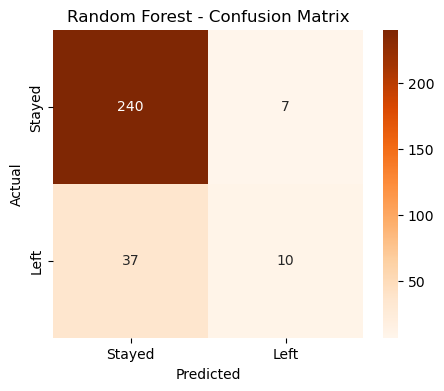

In [46]:
# Confusion Matrix
cm = confusion_matrix(y_test, gb_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Oranges',xticklabels=["Stayed","Left"],yticklabels=["Stayed","Left"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [47]:
 # Identify and clearly state which model performed best and why
comparison = pd.DataFrame({"Model":[ "Logistic Regression","Random Forest","Gradient Boosting"],
                           "Accuracy":[log_accuracy,rf_accuracy,gb_accuracy],
                           "Precision":[log_precision,rf_precision,gb_precision],
                           "Recall":[log_recall, rf_recall,gb_recall],
                           "F1 Score":[log_f1,rf_f1,gb_f1],
                           "ROC-AUC":[log_auc,rf_auc,gb_auc]
})
comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.751701,0.345238,0.617021,0.442748,0.697175
1,Random Forest,0.836735,0.444444,0.085106,0.142857,0.532432
2,Gradient Boosting,0.850340,0.588235,0.212766,0.312500,0.592213


In [48]:
# Best Model
comparison.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.751701,0.345238,0.617021,0.442748,0.697175
2,Gradient Boosting,0.850340,0.588235,0.212766,0.312500,0.592213
1,Random Forest,0.836735,0.444444,0.085106,0.142857,0.532432


# Best Model

In [49]:
# Among the three models,Logistic Regression achieved the highest F1-Score and ROC-AUC score. 
# It provided the best balance between identifying employees who are likely to leave (Recall) and avoiding incorrect predictions (Precision). 
# Therefore, Logistic Regression was selected as the best-performing model for predicting employee attrition.

In [50]:
# For the best model: extract Feature Importance — which factors matter most in predicting attrition?
feature_importance = pd.DataFrame({"Feature": X.columns,"Importance": abs(log_model.coef_[0])})
feature_importance = feature_importance.sort_values(by="Importance",ascending=False)
feature_importance.head(10)

,Feature,Importance
34,JobRole_Laboratory Technician,0.810172
43,OverTime_Yes,0.771095
23,BusinessTravel_Travel_Frequently,0.722538
16,TotalWorkingYears,0.660270
7,JobLevel,0.650173
40,JobRole_Sales Representative,0.531090
24,BusinessTravel_Travel_Rarely,0.512780
27,EducationField_Life Sciences,0.512319
21,YearsSinceLastPromotion,0.499063
26,Department_Sales,0.470587


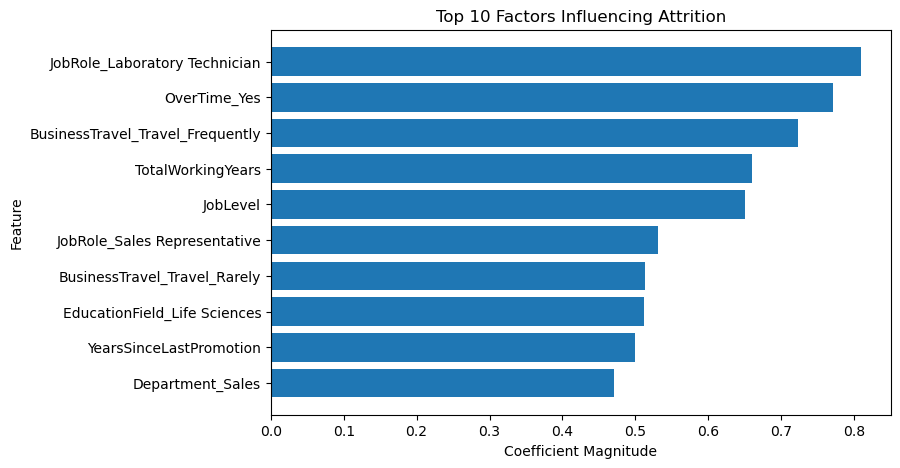

In [51]:
# Rank the top 10 most important features driving employee exit
top10 = feature_importance.head(10)
plt.figure(figsize=(8,5))
plt.barh(top10["Feature"], top10["Importance"])
plt.xlabel("Coefficient Magnitude")
plt.ylabel("Feature")
plt.title("Top 10 Factors Influencing Attrition")
plt.gca().invert_yaxis()
plt.show()

# Task 6 — Visualization (Minimum 4 charts)

Attrition                      No        Yes
Department                                  
Human Resources         80.952381  19.047619
Research & Development  86.160250  13.839750
Sales                   79.372197  20.627803


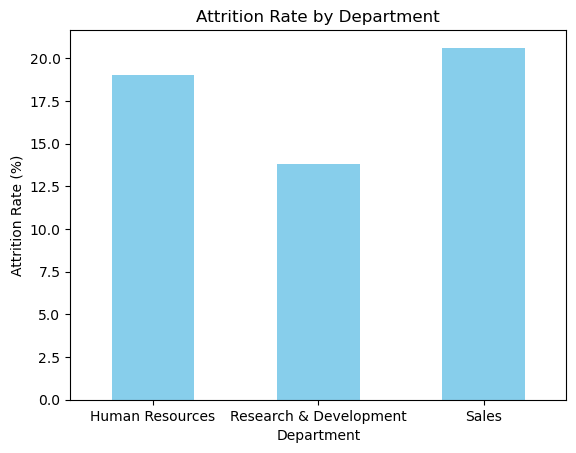

In [52]:
# Chart 1: Bar chart showing attrition rate by Department
depart_attrition = (eda_df.groupby("Department")["Attrition"].value_counts(normalize=True).unstack() * 100)
print(depart_attrition)
depart_attrition["Yes"].plot(kind="bar", color="skyblue")
plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.show()

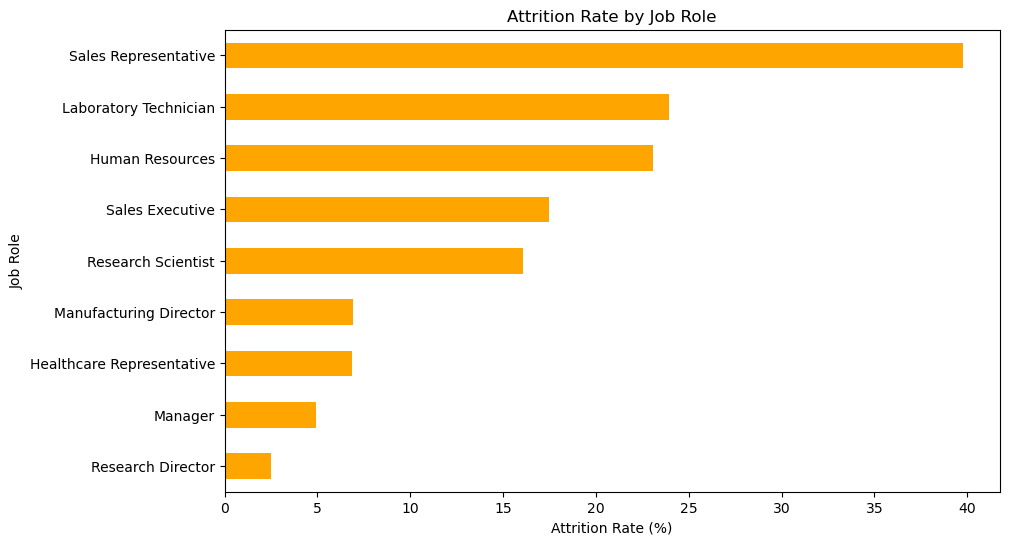

In [53]:
# Chart 1: Bar chart showing attrition rate by JobRole
jobrole_attrition = (eda_df.groupby("JobRole")["Attrition"].value_counts(normalize=True).unstack() * 100)
plt.figure(figsize=(10,6))
jobrole_attrition["Yes"].sort_values().plot(kind="barh", color="orange")
plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")
plt.show()

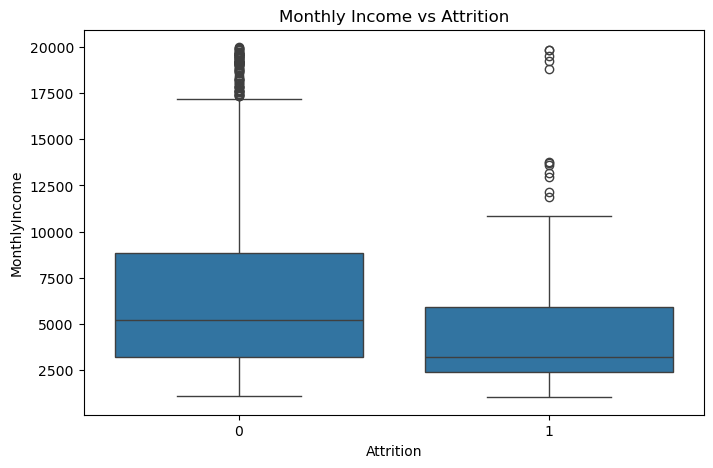

In [54]:
# ● Chart 2: Box plot comparing Monthly Income of employees who left vs stayed
plt.figure(figsize=(8,5))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

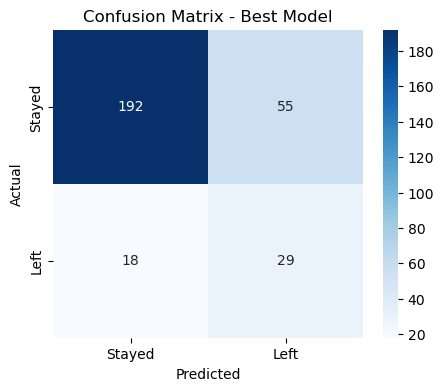

In [55]:
# ● Chart 3: Confusion Matrix heatmap for your best model
best_pred = log_pred
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Stayed","Left"],yticklabels=["Stayed","Left"])
plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

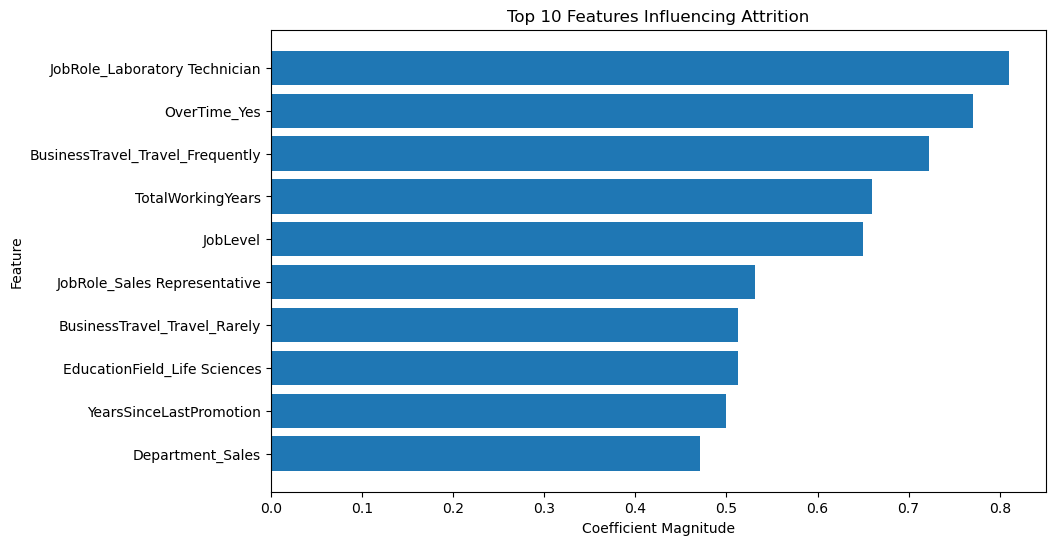

In [56]:
# ● Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model
feature_importance = pd.DataFrame({"Feature": X.columns,"Importance": abs(log_model.coef_[0])})
feature_importance = feature_importance.sort_values(by="Importance",ascending=False)
top10 = feature_importance.head(10)
plt.figure(figsize=(10,6))
plt.barh(top10["Feature"],top10["Importance"])
plt.title("Top 10 Features Influencing Attrition")
plt.xlabel("Coefficient Magnitude")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

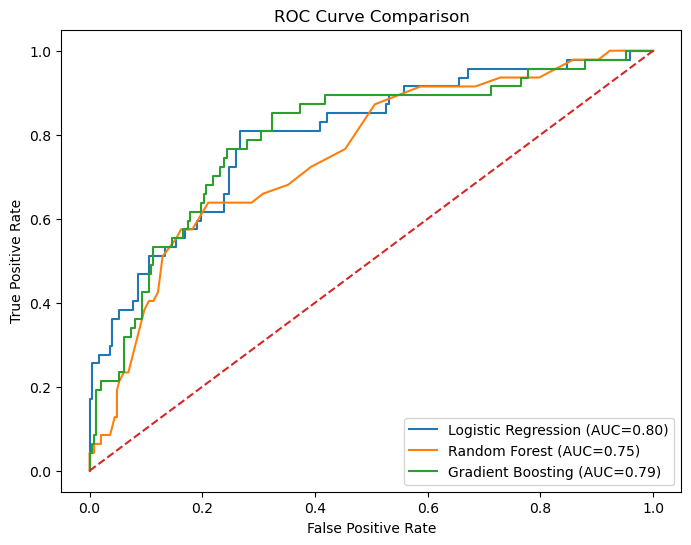

In [57]:
# ● Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph
from sklearn.metrics import roc_curve, auc
log_prob = log_model.predict_proba(X_test_scal)[:,1]
rf_prob = rf_model.predict_proba(X_test)[:,1]
gb_prob = gb_model.predict_proba(X_test)[:,1]
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)
auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)
auc_gb = auc(fpr_gb, tpr_gb)
plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log,label=f"Logistic Regression (AUC={auc_log:.2f})")
plt.plot(fpr_rf, tpr_rf,label=f"Random Forest (AUC={auc_rf:.2f})")
plt.plot(fpr_gb, tpr_gb,label=f"Gradient Boosting (AUC={auc_gb:.2f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# Task 7 — HR Insights & Business Recommendations

# ● Which 3 factors most strongly predict that an employee will leave? 

In [60]:
# The three factors that most strongly predict employee attrition are being a Laboratory Technician, working overtime, and frequent business travel. 
# Employees in the Laboratory Technician role show a higher likelihood of leaving the company compared to other job roles.
# Similarly, employees who regularly work overtime are more likely to experience stress and work-life imbalance, increasing their chances of resignation. Frequent business travel is also associated with higher attrition, suggesting that extensive travel requirements may negatively impact employee satisfaction and retention.

In [61]:
feature_importance.head(10)

,Feature,Importance
34,JobRole_Laboratory Technician,0.810172
43,OverTime_Yes,0.771095
23,BusinessTravel_Travel_Frequently,0.722538
16,TotalWorkingYears,0.660270
7,JobLevel,0.650173
40,JobRole_Sales Representative,0.531090
24,BusinessTravel_Travel_Rarely,0.512780
27,EducationField_Life Sciences,0.512319
21,YearsSinceLastPromotion,0.499063
26,Department_Sales,0.470587


# ● Which department or job role should HR prioritize for retention efforts?

In [62]:
# HR should prioritize the Sales department and Laboratory Technician job role for retention efforts. 
# These groups showed the highest impact on attrition in the analysis, indicating that employees in these areas are more likely to leave the organization.

# ● Does salary alone explain attrition or are there other stronger factors?

In [63]:
# Salary is not the only factor influencing attrition.
# While compensation can affect an employee's decision to stay, the analysis shows that other factors such as job role, overtime, and frequent business travel have a stronger impact on predicting employee turnover. In particular, Laboratory Technicians, employees who work overtime, and those who travel frequently are more likely to leave the company. 
# This suggests that work conditions, job responsibilities, and work-life balance are also important drivers of attrition and should be considered alongside salary when developing retention strategies.

# ● Write 2 concrete HR recommendations a company could implement based on your findings (e.g., specific policy changes, who to target for a retention conversation)

In [65]:
# 1. Target employees who work overtime and travel frequently for retention conversations. Since overtime and frequent business travel are among the strongest predictors of attrition, HR should regularly check in with these employees, monitor their workload, and offer flexible work arrangements or additional support to improve work-life balance.

In [66]:
# 2. Develop a retention program for Laboratory Technicians and employees in the Sales department. HR can provide clear career growth opportunities, skill development programs, mentorship, and recognition initiatives for these employees, as they have shown a higher likelihood of leaving the organization according to the analysis.

# ● What limitation does this model have that an HR team should be aware of before using it?

In [ ]:
# One limitation of this model is that it relies only on historical employee data and cannot capture personal or external factors that may influence an employee's decision to leave, such as family responsibilities, health issues, workplace relationships, or better job opportunities elsewhere.
# Therefore, the model should be used as a support tool to identify at-risk employees, rather than as the sole basis for HR decisions. 
# Human judgment and employee feedback should always be considered alongside the model's predictions.